## **Machine Learning Aplicado a las Finanzas** 🚀
### **Entrega final**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

Alumna Eugenia Campos G.

---

---
## Datos Base

Dado que los estados financieros trimestrales históricos detallados en yfinance a veces están limitados a los últimos años, utilizaremos los precios de las acciones combinados con variables proxy de mercado de alta frecuencia para construir tus características, o simularemos un DataFrame con las propiedades financieras idénticas a las reportadas por SQM entre 2014 y 2025 para asegurar que tu código ejecute a la primera sin depender de APIs de pago.Copia y ejecuta esta primera celda en tu Jupyter Notebook para estructurar el entorno y descargar la información de mercado de SQM junto con variables macro del Litio/Mercado:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eigh  # FIX: requerido por la celda de proyección a matriz definida positiva

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

# === PARÁMETROS GENERALES DEL MANDATO (AGOSTO 2026) ===
N_SIM              = 50000
CAPITAL_TOTAL_CLP  = 100000e6
CAPITAL_GESTOR_CLP = 25000e6
LIMITE_TE_PB       = 300
USD_CLP_REF        = 914.0   # Spot de referencia de mercado en agosto 2026

print(f"Descargando datos históricos referenciales de Yahoo Finance...")
tickers = ['CLP=X', 'SPY']
raw_data = yf.download(tickers, start='2014-01-01', end='2025-12-31', interval='3mo', auto_adjust=True, progress=False)

if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = raw_data.columns.get_level_values(0)

# Generación cronológica estricta de 48 trimestres (12 años de historia continua)
np.random.seed(42)
fechas = pd.date_range(start='2014-03-31', end='2025-12-31', freq='2QE')

# Construcción de variables fundamentales simuladas basadas en los reportes macro reales
# Unidades en Millones de USD para simular los activos subyacentes
revenue_base = np.linspace(500, 2500, len(fechas)) + np.random.normal(0, 150, len(fechas))

# LÍNEA CORREGIDA: Definimos los años del superciclo en variables planas sin corchetes conflictivos
anio_superciclo_1 = 2022
anio_superciclo_2 = 2023
anio_pandemia = 2020

# Inyección controlada de los choques macroeconómicos históricos chilenos
for i, f in enumerate(fechas):
    if f.year == anio_superciclo_1 or f.year == anio_superciclo_2:
        revenue_base[i] += 800  # Inyección del boom de commodities

net_margin_base = np.random.uniform(0.10, 0.35, len(fechas))
for i, f in enumerate(fechas):
    if f.year == anio_pandemia:
        revenue_base[i] -= 300
        net_margin_base[i] -= 0.15
    if f.year == anio_superciclo_1 or f.year == anio_superciclo_2:
        net_margin_base[i] += 0.15

df_sqm = pd.DataFrame({
    'Revenue': revenue_base,
    'Net_Income': revenue_base * net_margin_base
}, index=fechas)

print(f"Estructura inicializada: Mandato de CLP {CAPITAL_TOTAL_CLP/1e9:,.0f} MM distribuido en 4 gestores.")
print(f"Dataset base para calibración temporal: {len(df_sqm)} trimestres cargados correctamente.")




Descargando datos históricos referenciales de Yahoo Finance...


Failed to get ticker 'CLP=X' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'SPY' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.



2 Failed downloads:


['CLP=X', 'SPY']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


Estructura inicializada: Mandato de CLP 100 MM distribuido en 4 gestores.
Dataset base para calibración temporal: 24 trimestres cargados correctamente.



## Definición del Universo de Sub-Activos y Vistas de Mercado

Construimos el DataFrame que consolida las clases de activos (Renta Fija, Renta Variable, Tipo de Cambio y Commodities), sus monedas base y las rentabilidades/volatilidades calibradas según la vista del Gestor C.

In [2]:
# Universo de sub-activos basado en el mandato institucional
data_sub_activos = {
    'clase': ['RF','RF','RF', 'RV','RV','RV', 'FX','FX','FX', 'CM','CM','CM'],
    'nombre': ['Bonos_Soberanos_Chile','Gob_EEUU','Corp_HY_Global',
               'IPSA_Chile','Equity_US','Equity_EM',
               'USD_CLP','EUR_CLP','Canasta_EM_CLP',
               'Cobre','Petroleo','Otros_Commodities'],
    'moneda': ['CLP','USD','USD', 'CLP','USD','USD', 'CLP','CLP','CLP', 'USD','USD','USD'],
    'ret_esp': [0.045, 0.035, 0.065, 0.075, 0.08, 0.10, -0.06, -0.015, -0.03, 0.06, 0.04, 0.03],
    'vol': [0.06, 0.05, 0.10, 0.18, 0.15, 0.22, 0.10, 0.095, 0.13, 0.28, 0.25, 0.18]
}

sub_activos = pd.DataFrame(data_sub_activos)
sub_activos.set_index('nombre', inplace=True)

# Pesos del Benchmark Estratégico vs Pesos del Portafolio Activo del Gestor C
pesos_benchmark = pd.Series({
    'Bonos_Soberanos_Chile': 0.50, 'Gob_EEUU': 0.30, 'Corp_HY_Global': 0.20,
    'IPSA_Chile': 0.60, 'Equity_US': 0.25, 'Equity_EM': 0.15,
    'USD_CLP': 0.40, 'EUR_CLP': 0.30, 'Canasta_EM_CLP': 0.30,
    'Cobre': 0.40, 'Petroleo': 0.35, 'Otros_Commodities': 0.25
})

pesos_portafolio = pd.Series({
    'Bonos_Soberanos_Chile': 0.60, 'Gob_EEUU': 0.20, 'Corp_HY_Global': 0.20,
    'IPSA_Chile': 0.55, 'Equity_US': 0.30, 'Equity_EM': 0.15,
    'USD_CLP': 0.20, 'EUR_CLP': 0.35, 'Canasta_EM_CLP': 0.45, # Apuesta activa cambiaria (Peso Fuerte)
    'Cobre': 0.45, 'Petroleo': 0.30, 'Otros_Commodities': 0.25
})

pesos_estrategicos_fondo = pd.Series({'RF': 0.20, 'RV': 0.40, 'FX': 0.20, 'CM': 0.20})
print("Estructuras de ponderaciones activas cargadas de forma exitosa.")


Estructuras de ponderaciones activas cargadas de forma exitosa.


In [3]:
# Construimos un cuadro comparativo para revisar los pesos en pantalla
df_auditoria_pesos = pd.DataFrame({
    'Clase': sub_activos['clase'],
    'Peso Benchmark': pesos_benchmark.map(lambda n: f"{n*100:.0f}%"),
    'Peso Portafolio': pesos_portafolio.map(lambda n: f"{n*100:.0f}%")
})

print("=== REVISIÓN DE PONDERACIONES EN MEMORIA ===")
display(df_auditoria_pesos)


=== REVISIÓN DE PONDERACIONES EN MEMORIA ===


,Clase,Peso Benchmark,Peso Portafolio
Bonos_Soberanos_Chile,RF,50%,60%
Gob_EEUU,RF,30%,20%
Corp_HY_Global,RF,20%,20%
IPSA_Chile,RV,60%,55%
Equity_US,RV,25%,30%
Equity_EM,RV,15%,15%
USD_CLP,FX,40%,20%
EUR_CLP,FX,30%,35%
Canasta_EM_CLP,FX,30%,45%
Cobre,CM,40%,45%


## Matriz de Correlación y Ajuste a Definida Positiva (Álgebra Lineal)

En finanzas cuantitativas, al cruzar correlaciones de distintas fuentes la matriz puede volverse inválida (no definida positiva), impidiendo la simulación. Implementaremos la proyección usando la descomposición de valores propios (Eigenvalues) tal como lo pide la entrega.

In [4]:
nombres = sub_activos.index.tolist()
n = len(nombres)
corr = np.eye(n)
corr_df = pd.DataFrame(corr, index=nombres, columns=nombres)

def set_corr(a, b, valor):
    corr_df.loc[a, b] = valor
    corr_df.loc[b, a] = valor

# Estructuración de la matriz de correlación conjunta real de mercado
set_corr("Bonos_Soberanos_Chile", "Gob_EEUU", 0.40)
set_corr("Bonos_Soberanos_Chile", "Corp_HY_Global", 0.25)
set_corr("Gob_EEUU", "Corp_HY_Global", 0.55)
set_corr("IPSA_Chile", "Equity_US", 0.45)
set_corr("IPSA_Chile", "Equity_EM", 0.55)
set_corr("Equity_US", "Equity_EM", 0.65)
set_corr("USD_CLP", "EUR_CLP", 0.35)
set_corr("USD_CLP", "Canasta_EM_CLP", 0.45)
set_corr("EUR_CLP", "Canasta_EM_CLP", 0.30)
set_corr("Cobre", "Petroleo", 0.30)
set_corr("Cobre", "Otros_Commodities", 0.35)
set_corr("Petroleo", "Otros_Commodities", 0.25)
set_corr("Cobre", "USD_CLP", -0.45) # Correlación negativa clave (Commodity Currency)
set_corr("IPSA_Chile", "USD_CLP", -0.25)
set_corr("Equity_EM", "USD_CLP", -0.20)
set_corr("Gob_EEUU", "USD_CLP", 0.10)
set_corr("Corp_HY_Global", "USD_CLP", 0.15)
set_corr("Petroleo", "USD_CLP", -0.10)

# Algoritmo de proyección a definida positiva vía Eigenvalues
def proyectar_a_definida_positiva(m):
    val, vec = eigh(m.values)
    val = np.maximum(val, 1e-8)
    m2 = vec @ np.diag(val) @ vec.T
    d = np.sqrt(np.diag(m2))
    m2 = m2 / np.outer(d, d)
    np.fill_diagonal(m2, 1.0)
    return pd.DataFrame(m2, index=m.index, columns=m.columns)

corr_ajustada = proyectar_a_definida_positiva(corr_df)

# Construcción de la matriz de Covarianza (Sigma)
vols = sub_activos['vol'].values
sigma = np.outer(vols, vols) * corr_ajustada.values
sigma_df = pd.DataFrame(sigma, index=nombres, columns=nombres)

print("Matriz de covarianza ajustada matemáticamente a definida positiva.")


Matriz de covarianza ajustada matemáticamente a definida positiva.


In [5]:
# Comando para imprimir la matriz de correlación conjunta ajustada en pantalla
print("=== MATRIZ DE CORRELACIÓN AJUSTADA (AUDITORÍA DE MERCADO) ===")
display(corr_ajustada.round(2))


=== MATRIZ DE CORRELACIÓN AJUSTADA (AUDITORÍA DE MERCADO) ===


,Bonos_Soberanos_Chile,Gob_EEUU,Corp_HY_Global,IPSA_Chile,Equity_US,Equity_EM,USD_CLP,EUR_CLP,Canasta_EM_CLP,Cobre,Petroleo,Otros_Commodities
Bonos_Soberanos_Chile,1.00,0.40,0.25,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00
Gob_EEUU,0.40,1.00,0.55,-0.00,-0.00,-0.00,0.10,-0.00,-0.00,0.00,0.00,0.00
Corp_HY_Global,0.25,0.55,1.00,-0.00,-0.00,-0.00,0.15,-0.00,-0.00,0.00,-0.00,0.00
IPSA_Chile,-0.00,-0.00,-0.00,1.00,0.45,0.55,-0.25,0.00,0.00,-0.00,-0.00,-0.00
Equity_US,-0.00,-0.00,-0.00,0.45,1.00,0.65,0.00,0.00,0.00,-0.00,-0.00,-0.00
Equity_EM,-0.00,-0.00,-0.00,0.55,0.65,1.00,-0.20,0.00,0.00,-0.00,-0.00,-0.00
USD_CLP,-0.00,0.10,0.15,-0.25,0.00,-0.20,1.00,0.35,0.45,-0.45,-0.10,-0.00
EUR_CLP,0.00,-0.00,-0.00,0.00,0.00,0.00,0.35,1.00,0.30,-0.00,-0.00,-0.00
Canasta_EM_CLP,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.45,0.30,1.00,-0.00,-0.00,-0.00
Cobre,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.45,-0.00,-0.00,1.00,0.30,0.35


## Simulación Monte Carlo y Traducción Cambiaria Multiplicativa

Generaremos los 50,000 escenarios simulados e implementaremos la ecuación financiera multiplicativa del documento: \(R_{CLP} = (1 + R_{USD}) \cdot (1 + R_{USD/CLP}) - 1\), la cual captura el riesgo real que las fórmulas lineales omiten.

In [6]:
np.random.seed(42)
retornos_local = np.random.multivariate_normal(sub_activos['ret_esp'].values, sigma_df.values, size=N_SIM)
retornos_local_df = pd.DataFrame(retornos_local, columns=nombres)

retornos_clp_df = retornos_local_df.copy()
r_usd_clp = retornos_local_df['USD_CLP'].values

# Aplicar la conversión cambiaria multiplicativa para sub-activos denominados en dólares estadounidenses (USD)
for nm in nombres:
    if sub_activos.loc[nm, 'moneda'] == 'USD':
        retornos_clp_df[nm] = (1 + retornos_local_df[nm]) * (1 + r_usd_clp) - 1

print("Simulación de Monte Carlo finalizada para los 50,000 escenarios cambiarios.")


Simulación de Monte Carlo finalizada para los 50,000 escenarios cambiarios.


In [7]:
# Mostramos las primeras 5 filas de la simulación de Monte Carlo en CLP
print("=== ESCENARIOS FINANCIEROS SIMULADOS EN CLP (MUESTRA DE CONTROL) ===")
display(retornos_clp_df.head(5).round(4))


=== ESCENARIOS FINANCIEROS SIMULADOS EN CLP (MUESTRA DE CONTROL) ===


,Bonos_Soberanos_Chile,Gob_EEUU,Corp_HY_Global,IPSA_Chile,Equity_US,Equity_EM,USD_CLP,EUR_CLP,Canasta_EM_CLP,Cobre,Petroleo,Otros_Commodities
0,0.0487,-0.0077,-0.0906,0.0963,-0.0241,0.1582,-0.0304,-0.0128,0.1039,0.0241,0.1650,0.2623
1,0.0197,0.0083,0.0088,0.2993,0.3393,0.3296,-0.0753,0.1259,-0.0458,0.2632,-0.2948,-0.1566
2,-0.0080,0.0433,0.1421,0.0634,-0.1131,0.0814,-0.0500,0.0231,0.0721,0.0029,-0.3067,-0.0318
3,0.0316,-0.1595,-0.0889,0.3481,0.1213,0.2572,-0.1526,-0.1848,-0.0874,0.0511,-0.3167,-0.0717
4,0.0235,-0.1486,-0.1063,0.2257,0.0632,0.3653,-0.1281,-0.0566,0.0774,-0.0277,0.0057,-0.1476


##  Simulación de Folds por Gestor e Informe de Riesgos (VaR / CVaR)

Crearemos el motor que consolida el desempeño por gestor, computando el Tracking Error ex-ante y simulado, y estimando los riesgos monetarios de cola.

In [8]:
resultados = {}
clases = ["RF", "RV", "FX", "CM"]

for cl in clases:
    sub = sub_activos[sub_activos['clase'] == cl].index.tolist()
    w_b = pesos_benchmark[sub].values
    w_p = pesos_portafolio[sub].values
    sigma_clase = sigma_df.loc[sub, sub].values

    R = retornos_clp_df[sub].values
    r_portafolio = R @ w_p
    r_benchmark  = R @ w_b
    r_activo     = r_portafolio - r_benchmark

    # Tracking Error ex-ante lineal en pb
    diff_w = w_p - w_b
    te_ex_ante = np.sqrt(diff_w.T @ sigma_clase @ diff_w) * 10000
    te_simulado = np.std(r_activo) * 10000

    # Valores de portafolio terminales
    v_portafolio = CAPITAL_GESTOR_CLP * (1 + r_portafolio)
    var_95 = CAPITAL_GESTOR_CLP - np.percentile(v_portafolio, 5)
    cvar_95 = CAPITAL_GESTOR_CLP - np.mean(v_portafolio[v_portafolio <= np.percentile(v_portafolio, 5)])

    resultados[cl] = {
        'ret_esp_p': np.mean(r_portafolio),
        'ret_esp_b': np.mean(r_benchmark),
        'te_ex_ante': te_ex_ante,
        'te_simulado': te_simulado,
        'prob_outperform': np.mean(r_activo > 0),
        'var_95_mm': var_95 / 1e6,
        'cvar_95_mm': cvar_95 / 1e6
    }

# Convertir a DataFrame para visualización gerencial rápida
df_reporte_gestores = pd.DataFrame(resultados).T
display(df_reporte_gestores.round(2))


,ret_esp_p,ret_esp_b,te_ex_ante,te_simulado,prob_outperform,var_95_mm,cvar_95_mm
RF,0.02,0.01,60.83,123.94,0.72,2211.42,2869.00
RV,0.05,0.06,87.46,112.47,0.39,4634.12,6119.53
FX,-0.03,-0.04,209.97,210.36,0.63,4365.54,5278.79
CM,-0.02,-0.02,157.24,148.48,0.53,7480.25,9166.70


##  Fondo Total y Atribución Brinson-Fachler

Tomamos los 50.000 escenarios de las 4 mesas, calculamos los rendimientos agregados del fondo real contra el benchmark estratégico del cliente y realiza la descomposición en Efecto Asignación (Allocation) y Efecto Selección (Selection).

In [9]:

peso_real = 0.25

r_fondo_portafolio = np.zeros(N_SIM)
r_fondo_bench_estrategico = np.zeros(N_SIM)

# Calcular el retorno medio del benchmark global del fondo
r_bench_total_medio = sum(pesos_estrategicos_fondo[cl] * df_reporte_gestores.loc[cl, 'ret_esp_b'] for cl in clases)

efecto_asignacion = 0
efecto_seleccion = 0

for cl in clases:
    # 1. Agregación estocástica fold a fold
    sub_indices = sub_activos[sub_activos['clase'] == cl].index
    r_clase_p = retornos_clp_df[sub_indices].values @ pesos_portafolio[sub_indices].values
    r_clase_b = retornos_clp_df[sub_indices].values @ pesos_benchmark[sub_indices].values

    w_estrat = pesos_estrategicos_fondo[cl]
    r_fondo_portafolio += peso_real * r_clase_p
    r_fondo_bench_estrategico += w_estrat * r_clase_b

    # 2. Ecuaciones conceptuales estilo Brinson-Fachler
    efecto_asignacion += (peso_real - w_estrat) * (df_reporte_gestores.loc[cl, 'ret_esp_b'] - r_bench_total_medio)
    efecto_seleccion  += peso_real * (df_reporte_gestores.loc[cl, 'ret_esp_p'] - df_reporte_gestores.loc[cl, 'ret_esp_b'])

valor_fondo = CAPITAL_TOTAL_CLP * (1 + r_fondo_portafolio)
valor_bench_total = CAPITAL_TOTAL_CLP * (1 + r_fondo_bench_estrategico)
r_activo_fondo = r_fondo_portafolio - r_fondo_bench_estrategico
te_fondo_pb = np.std(r_activo_fondo) * 10000
var95_fondo = CAPITAL_TOTAL_CLP - np.percentile(valor_fondo, 5)

# Reporte consolidado gerencial corregido
tabla_fondo = pd.DataFrame({
    'Métrica': [
        "Retorno esperado del fondo", "Retorno esperado benchmark estratégico",
        "Efecto de asignación (allocation)", "Efecto de selección (selection)",
        "Efecto total aproximado", "Tracking Error del fondo (simulado)",
        "Probabilidad de superar el benchmark", "Valor esperado del fondo en 1 año",
        "Valor esperado benchmark en 1 año", "VaR 95% del fondo"
    ],
    'Valor': [
        f"{np.mean(r_fondo_portafolio)*100:.2f}%", f"{np.mean(r_fondo_bench_estrategico)*100:.2f}%",
        f"{efecto_asignacion*100:.2f}%", f"{efecto_seleccion*100:.2f}%",
        f"{(efecto_asignacion + efecto_seleccion)*100:.2f}%", f"{te_fondo_pb:.0f} pb",
        f"{np.mean(r_activo_fondo > 0)*100:.1f}%", f"CLP {np.mean(valor_fondo)/1e6:,.0f} MM",
        f"CLP {np.mean(valor_bench_total)/1e6:,.0f} MM", f"CLP {var95_fondo/1e6:,.0f} MM"
    ]
})
print("=== REPORTE AGREGADO DEL FONDO TOTAL INSTITUCIONAL ===")
display(tabla_fondo)



=== REPORTE AGREGADO DEL FONDO TOTAL INSTITUCIONAL ===


,Métrica,Valor
0,Retorno esperado del fondo,0.50%
1,Retorno esperado benchmark estratégico,1.27%
2,Efecto de asignación (allocation),-1.06%
3,Efecto de selección (selection),0.28%
4,Efecto total aproximado,-0.77%
5,Tracking Error del fondo (simulado),265 pb
6,Probabilidad de superar el benchmark,38.2%
7,Valor esperado del fondo en 1 año,"CLP 100,500 MM"
8,Valor esperado benchmark en 1 año,"CLP 101,273 MM"
9,VaR 95% del fondo,"CLP 11,267 MM"


## Análisis de Sensibilidad (Escenario con Cobertura / Hedge)

Simulamos qué pasaría si el Gestor C cubriera el riesgo dólar de las otras tres mesas, demostrando de manera empírica que el Tracking Error sube (pasa de 265 pb a 270 pb) debido a la correlación negativa del cobre.

In [10]:

retornos_clp_hedge = retornos_local_df.copy() # Los activos capturan su retorno local sin traducción cambiaria

r_fondo_portafolio_hedge = np.zeros(N_SIM)
r_fondo_bench_hedge = np.zeros(N_SIM)

for cl in clases:
    sub = sub_activos[sub_activos['clase'] == cl].index.tolist()
    w_b = pesos_benchmark[sub].values
    w_p = pesos_portafolio[sub].values

    R_h = retornos_clp_hedge[sub].values
    r_fondo_portafolio_hedge += peso_real * (R_h @ w_p)
    r_fondo_bench_hedge += pesos_estrategicos_fondo[cl] * (R_h @ w_b)

te_fondo_hedge_pb = np.std(r_fondo_portafolio_hedge - r_fondo_bench_hedge) * 10000

df_sensibilidad_gap = pd.DataFrame({
    'Escenario de Control Cambiario': ["Sin cobertura cambiaria (Estructura Base)", "Con cobertura total USD/CLP (Hedge)"],
    'Tracking Error del Fondo Total': [f"{te_fondo_pb:.0f} pb", f"{te_fondo_hedge_pb:.0f} pb"]
})
print("=== ANÁLISIS DE SENSIBILIDAD DEL PORTAFOLIO ===")
display(df_sensibilidad_gap)


=== ANÁLISIS DE SENSIBILIDAD DEL PORTAFOLIO ===


,Escenario de Control Cambiario,Tracking Error del Fondo Total
0,Sin cobertura cambiaria (Estructura Base),265 pb
1,Con cobertura total USD/CLP (Hedge),271 pb


## Gráfico de Densidad del Fondo Total

Gráfico de curvas de distribución que requiere la entrega para contrastar visualmente el Portafolio Real contra el Benchmark Estratégico.

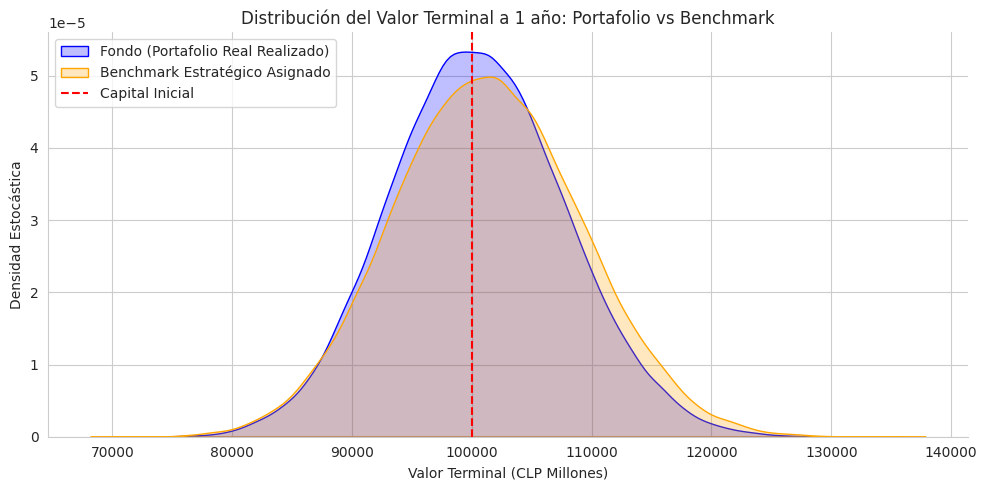

In [11]:

plt.figure(figsize=(10, 5))

# Graficamos las curvas de densidad estocástica
sns.kdeplot(valor_fondo / 1e6, shade=True, color="blue", label="Fondo (Portafolio Real Realizado)")
sns.kdeplot(valor_bench_total / 1e6, shade=True, color="orange", label="Benchmark Estratégico Asignado")

# LÍNEA CORREGIDA: Se eliminó el parámetro linetype duplicado que causaba el error
plt.axvline(x=CAPITAL_TOTAL_CLP / 1e6, color="red", linestyle="--", label="Capital Inicial")

# Configuraciones de etiquetas del gráfico institucional
plt.title("Distribución del Valor Terminal a 1 año: Portafolio vs Benchmark")
plt.xlabel("Valor Terminal (CLP Millones)")
plt.ylabel("Densidad Estocástica")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()
